# Implementation of a Neural Network for Iris dataset classification. Part 2: Training the Network

This notebook implements the functions required to train a multilayer neural network for classifying flower species in the Iris dataset.

The code is modularized into functions to facilitate understanding and step-by-step execution.

## Training process

The network is trained by a succession of forward and backward iteration steps, continuously adjusting the model parameters to minimize the error.

- **Forward propagation**: Computes the activations in each layer by applying weighted transformations and activation functions.
- **Loss computation**: Measures the difference between the predicted output and the actual target values.
- **Backward propagation**: Computes gradients by applying the chain rule to propagate the error backward through the network.
- **Weight update**: Adjusts the parameters using gradient descent or another optimization algorithm to reduce the loss in future iterations.

This process is repeated over multiple epochs until convergence or a stopping criterion is met.

### Activation functions

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    expX = np.exp(x - np.max(x, axis=1, keepdims=True))  # Estabilidad numérica
    return expX / np.sum(expX, axis=1, keepdims=True)


## Forward propagation

The network is trained  by a succession of forward and backward iteration steps
Forward propagation computes activations in each layer of the network.

1. **Hidden layer**:

$$ Z_h = X W_0 + b_0 $$
$$ A_h = \sigma(Z_h) = \frac{1}{1 + e^{-Z_h}} $$  

2. **Output layer**:

$$ Z_o = A_h W_1 + b_1 $$
$$ A_o = \text{softmax}(Z_o) = \frac{e^{Z_o}}{\sum e^{Z_o}} $$

Where $ \sigma(x) $ is the sigmoid function and softmax converts the outputs into probabilities.

And $A_h$ and $A_o$ are respectively the hideen layer and output layer activations.

In [3]:

def forward_propagation(X, W0, b0, W1, b1):
    Z_h = np.dot(X, W0) + b0
    A_h = sigmoid(Z_h)

    Z_o = np.dot(A_h, W1) + b1
    A_o = softmax(Z_o)

    return A_h, A_o



## Backpropagation

The error propagates backward to adjust weights using gradient descent.

1. **Error in the output layer**:

$$ \delta_o = A_o - Y $$

2. **Error in the hidden layer**:

$$ \delta_h = (\delta_o W_1^T) \cdot \sigma'(Z_h) $$

3. **Gradients to update weights**:

$$ W_1 \gets W_1 - \eta (A_h^T \delta_o) $$
$$ b_1 \gets b_1 - \eta \sum \delta_o $$

$$ W_0 \gets W_0 - \eta (X^T \delta_h) $$
$$ b_0 \gets b_0 - \eta \sum \delta_h $$

Where $ \sigma'(x) $ is the derivative of the activation function, here, the sigmoid function.


In [4]:

def sigmoid_deriv(x):
    return x * (1 - x)

def backpropagation(X, Y, A_h, A_o, W1):
    delta_o = A_o - Y

    dcost_dah = np.dot(delta_o, W1.T)
    delta_h = dcost_dah * sigmoid_deriv(A_h)

    return delta_o, delta_h


In [5]:

def update_weights(X, A_h, delta_o, delta_h, W0, b0, W1, b1, learning_rate):
    W1 -= learning_rate * np.dot(A_h.T, delta_o)
   # b1 -= learning_rate * np.sum(delta_o, axis=0, keepdims=True)
    b1 -= learning_rate * np.sum(delta_o, axis=0)

    W0 -= learning_rate * np.dot(X.T, delta_h)
   # b0 -= learning_rate * np.sum(delta_h, axis=0, keepdims=True)
    b0 -= learning_rate * np.sum(delta_h, axis=0)
    return W0, b0, W1, b1



## Initialization of weights and bias

Before training the network, weights and biases must be randomly initialized.
For the hidden layer ($ W_0 $, $ b_0 $) and the output layer ($ W_1 $, $ b_1 $):

$$ W_0 \in \mathbb{R}^{n_{input} \times n_{hidden}}, \quad b_0 \in \mathbb{R}^{1 \times n_{hidden}} $$
$$ W_1 \in \mathbb{R}^{n_{hidden} \times n_{output}}, \quad b_1 \in \mathbb{R}^{1 \times n_{output}} $$

Weights are randomly initialized  to break symmetry in learning.


In [6]:
def initialize_network(input_size, hidden_size, output_size):
    # Initialize the weights and biases of a neural network.
    W0 = 2*np.random.random((input_size, hidden_size)) - 1  # Input -> Hidden weights
    W1 = 2*np.random.random((hidden_size, output_size)) - 1   # Hidden -> Output weights
    b0 = np.random.randn(hidden_size)  # Hidden bias   
    b1 = np.random.randn(output_size)  # Output bias
    return [W0, b0, W1, b1]



## Neural network training

After setting the weights to their initial (usually random) values, the neural network is trained going through several iterations with all the data (*epochs*) where the output is computed by forward propagation and the difference among the output and the is true value is used to adjust the weights by backpropagating the error.

The process stops when convergence or a certain number of iterations is reached.


In [7]:
def train_neural_network(X_train, Y_train, epochs, learning_rate, batch_size, params):
    W0, b0, W1, b1 = params  # Unpack initial parameters
    num_samples = X_train.shape[0]
    
    # Calculate number of batches
    num_batches = num_samples // batch_size
    if num_samples % batch_size != 0:
        num_batches += 1  # Include last batch if not evenly divisible

    loss_history = []  # Track loss over epochs

    for epoch in range(epochs):
        for batch_idx in range(num_batches):
            # Define batch range
            batch_start = batch_idx * batch_size
            batch_end = min(batch_start + batch_size, num_samples)
            X_batch = X_train[batch_start:batch_end]
            Y_batch = Y_train[batch_start:batch_end]

            # Forward Propagation
            A_h, A_o = forward_propagation(X_batch, W0, b0, W1, b1)

            # Backpropagation
            delta_o, delta_h = backpropagation(X_batch, Y_batch, A_h, A_o, W1)

            # Weight update
            W0, b0, W1, b1 = update_weights(X_batch, A_h, delta_o, delta_h, W0, b0, W1, b1, learning_rate)

        # Compute loss every 100 epochs
        if epoch % 100 == 0:
            _, A_o = forward_propagation(X_train, W0, b0, W1, b1)  # Evaluate full dataset
            loss = -np.mean(Y_train * np.log(A_o + 1e-9))  # Avoid log(0)
            loss_history.append(loss)
            print(f"Epoch {epoch}, Loss: {loss:.4f}")

    return [W0, b0, W1, b1], loss_history  # Return trained parameters and loss history

# Training the network in practice

## Importing libraries

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## Load and prepare data

Data have been preprocessed elsewhere and they are ready to feed the network

In [12]:
# Load data from binary dataset
data = np.load("iris_train_test_data.npz")

# Extract data
X_train, y_train, X_test, y_test = data["X_train"], data["y_train"], data["X_test"], data["y_test"]

print("Dataset loaded successfully.")

Dataset loaded successfully.


## Initialize the network and hyperparameters

Setting the weights defines the architechture of the network (assuming full connectivity).

We set:

- input layer: 4 nodes (we use 4 features to train the network)
- hidden layer: 5 nodes
- output layer: 3 nodes

Additionally we must set the values of the parameters that will be used for training

learning_rate = 0.01
batch_size = 10
epochs = 1000


In [13]:
input_size=X_train.shape[1]
hidden_size=5 
output_size=3
np.random.seed(654321)

my_params = initialize_network(input_size, hidden_size, output_size)

In [14]:
# params_rounded = [np.round(param, 3) for param in my_params]
# params_rounded

In [15]:
learning_rate = 0.01
batch_size = 10
epochs = 1000
loss_history = []  # Store errors during training

## Train the network

Given the data, the parameters and the hyperparameters we can call the main training function.

In [16]:
trainedNet, loss_history = train_neural_network (X_train=X_train, Y_train=y_train, 
                                  epochs=epochs, learning_rate=learning_rate, batch_size=batch_size,
                                  params=my_params)

Epoch 0, Loss: 0.4157
Epoch 100, Loss: 0.2450
Epoch 200, Loss: 0.1517
Epoch 300, Loss: 0.1190
Epoch 400, Loss: 0.0915
Epoch 500, Loss: 0.0722
Epoch 600, Loss: 0.0596
Epoch 700, Loss: 0.0513
Epoch 800, Loss: 0.0456
Epoch 900, Loss: 0.0416


### Check model performance

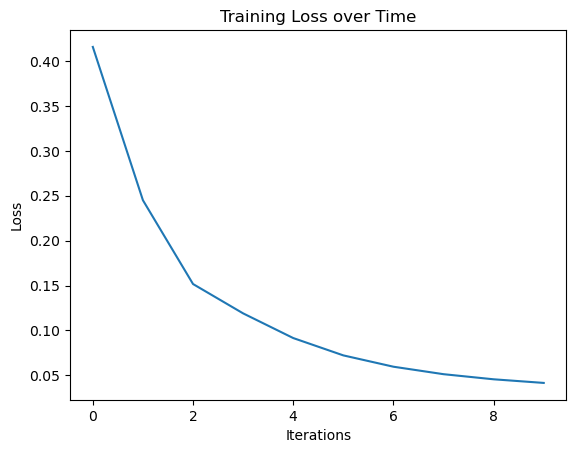

In [17]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss over Time")
plt.show()

### Evaluate network on test data

In [18]:
def evaluation(params, tst_set):
  w0 = params[0]
  bh = params[1]
  w1 = params[2]
  bo = params[3]

  # First layer propagation
  zh = np.dot(tst_set, w0) + bh
  layer1 = sigmoid(zh)

  # Second layer propagation
  zo = np.dot(layer1, w1) + bo
  layer2 = softmax(zo)

  return layer2.argmax(axis=1)  # Convert to class labels


In [19]:
y_pred = evaluation(trainedNet, X_test)


In [20]:
y_actual = pd.Series(y_test.argmax(axis=1))
y_pred = pd.Series(y_pred) 

cm = pd.crosstab(y_actual, y_pred).to_numpy()
cm

array([[14,  0,  0],
       [ 0, 12,  4],
       [ 0,  0, 15]], dtype=int64)

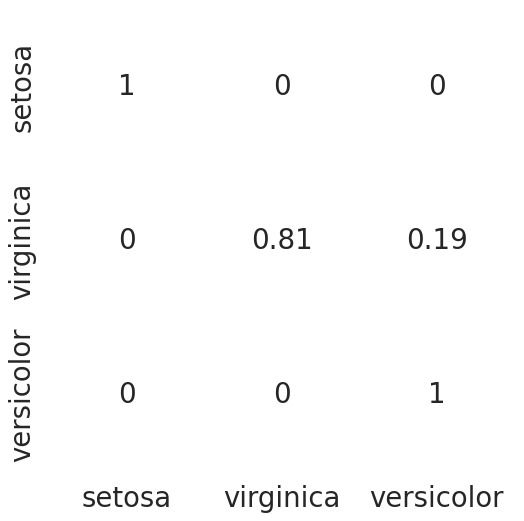

In [130]:
if cm.shape[1]<3:
  cm = np.concatenate((cm,np.zeros((3,3-cm.shape[1]))),axis=1)

cm_norm = np.array([cm[i][j]/cm[i].sum() for i in range(cm.shape[0]) for j in range(cm.shape[1])])
cm_norm = cm_norm.reshape(3,3)


import seaborn as sns
from matplotlib.colors import ListedColormap


df_cm = pd.DataFrame(cm_norm, index = ['setosa','virginica','versicolor'],
                  columns = ['setosa','virginica','versicolor'])

plt.figure(figsize = (6,6))

with sns.axes_style('white'):
    sns.heatmap(df_cm,
                cbar=False,
                square=False,
                annot=True,
                annot_kws={"size": 20},
                cmap=ListedColormap(['white']),
                linewidths=0.5)
    sns.set(font_scale=1.8)